<a href="https://colab.research.google.com/github/vasudhabobde/Machine_Learning_Practicals/blob/main/B3_B2_32_Vasudha_Bobde_MLDS_Practical_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

df = pd.read_csv("Country-data.csv")

df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [ ]:
print("Dataset Shape:", df.shape)

Dataset Shape: (167, 10)


In [ ]:
display(df.describe())

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,38.270060,41.108976,6.815689,46.890215,17144.688623,7.781832,70.555689,2.947964,12964.155689
std,40.328931,27.412010,2.746837,24.209589,19278.067698,10.570704,8.893172,1.513848,18328.704809
min,2.600000,0.109000,1.810000,0.065900,609.000000,-4.210000,32.100000,1.150000,231.000000
25%,8.250000,23.800000,4.920000,30.200000,3355.000000,1.810000,65.300000,1.795000,1330.000000
50%,19.300000,35.000000,6.320000,43.300000,9960.000000,5.390000,73.100000,2.410000,4660.000000
75%,62.100000,51.350000,8.600000,58.750000,22800.000000,10.750000,76.800000,3.880000,14050.000000
max,208.000000,200.000000,17.900000,174.000000,125000.000000,104.000000,82.800000,7.490000,105000.000000


In [ ]:
print(df.isnull().sum())

country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64


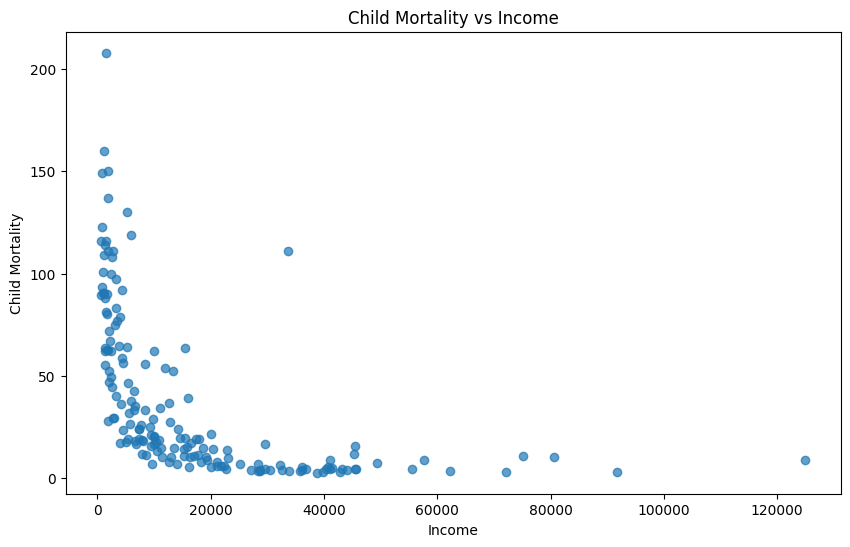

In [ ]:
plt.figure(figsize=(10, 6))

plt.scatter(df['income'], df['child_mort'], alpha=0.7)

plt.xlabel("Income")
plt.ylabel("Child Mortality")
plt.title("Child Mortality vs Income")

plt.show()

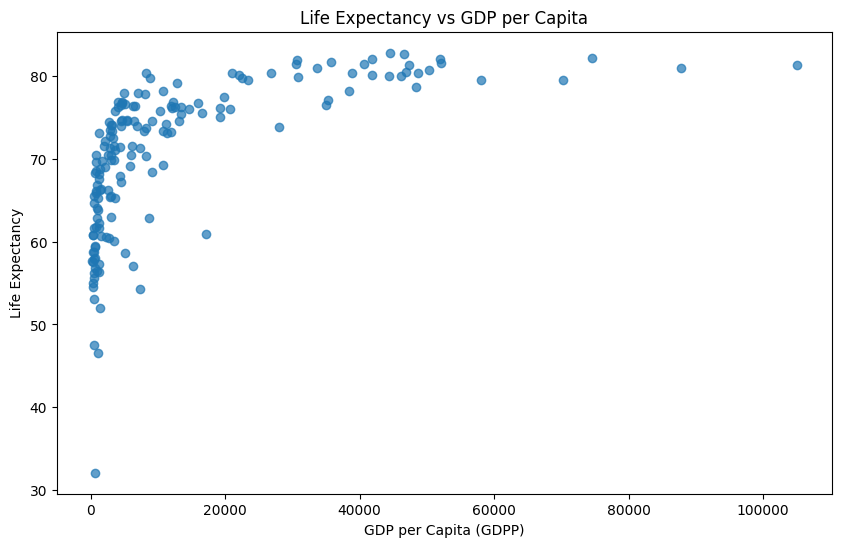

In [ ]:
plt.figure(figsize=(10, 6))

plt.scatter(df['gdpp'], df['life_expec'], alpha=0.7)

plt.xlabel("GDP per Capita (GDPP)")
plt.ylabel("Life Expectancy")
plt.title("Life Expectancy vs GDP per Capita")

plt.show()

In [ ]:
features = df.drop(columns=['country'])
print(features.columns)

Index(['child_mort', 'exports', 'health', 'imports', 'income', 'inflation',
       'life_expec', 'total_fer', 'gdpp'],
      dtype='object')


In [ ]:
scaler = StandardScaler()

scaled_features = scaler.fit_transform(features)

scaled_df = pd.DataFrame(
    scaled_features,
    columns=features.columns
)

scaled_df.head()


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,1.291532,-1.138280,0.279088,-0.082455,-0.808245,0.157336,-1.619092,1.902882,-0.679180
1,-0.538949,-0.479658,-0.097016,0.070837,-0.375369,-0.312347,0.647866,-0.859973,-0.485623
2,-0.272833,-0.099122,-0.966073,-0.641762,-0.220844,0.789274,0.670423,-0.038404,-0.465376
3,2.007808,0.775381,-1.448071,-0.165315,-0.585043,1.387054,-1.179234,2.128151,-0.516268
4,-0.695634,0.160668,-0.286894,0.497568,0.101732,-0.601749,0.704258,-0.541946,-0.041817


In [ ]:
wcss = []

for k in range(1, 13):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(scaled_features)
    wcss.append(kmeans.inertia_)

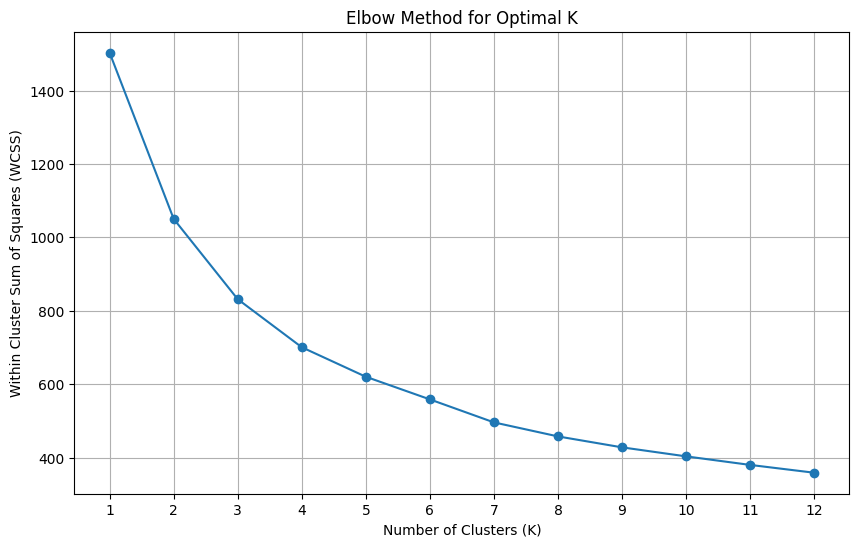

In [ ]:
plt.figure(figsize=(10, 6))

plt.plot(
    range(1, 13),
    wcss,
    marker='o'
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Within Cluster Sum of Squares (WCSS)")
plt.title("Elbow Method for Optimal K")
plt.xticks(range(1, 13))
plt.grid(True)

plt.show()

In [ ]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

df['Cluster'] = kmeans.fit_predict(scaled_features)

df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,Cluster
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553,1
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090,2
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460,2
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530,1
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200,2


In [ ]:
print(df['Cluster'].value_counts().sort_index())

Cluster
0    36
1    47
2    84
Name: count, dtype: int64


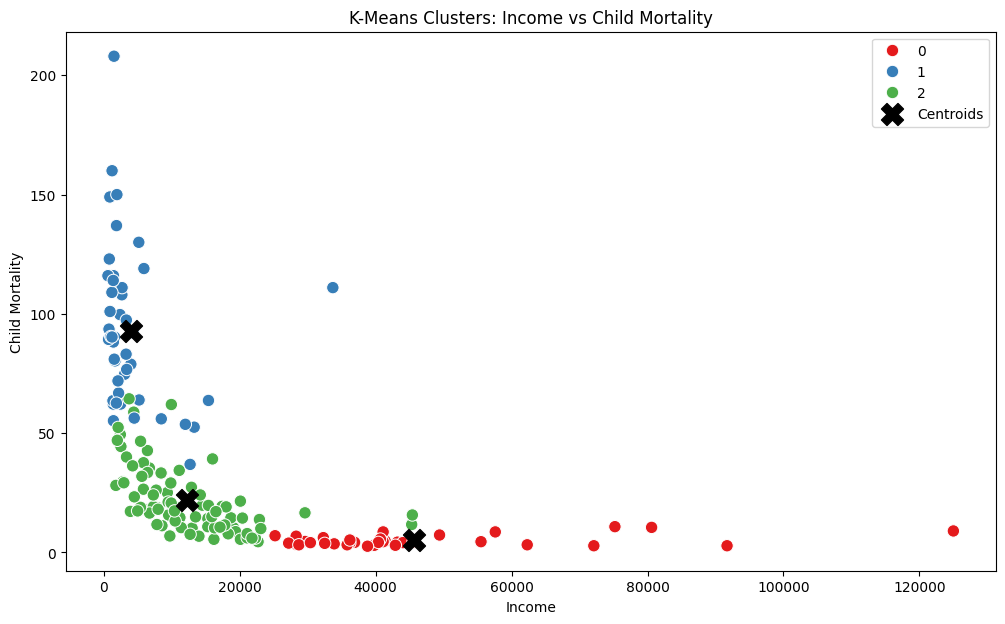

In [ ]:
plt.figure(figsize=(12, 7))

sns.scatterplot(
    data=df,
    x='income',
    y='child_mort',
    hue='Cluster',
    palette='Set1',
    s=80
)

# Transform cluster centers back to original scale
centers_original = scaler.inverse_transform(kmeans.cluster_centers_)

plt.scatter(
    centers_original[:, features.columns.get_loc('income')],
    centers_original[:, features.columns.get_loc('child_mort')],
    marker='X',
    s=250,
    c='black',
    label='Centroids'
)

plt.xlabel("Income")
plt.ylabel("Child Mortality")
plt.title("K-Means Clusters: Income vs Child Mortality")
plt.legend()

plt.show()

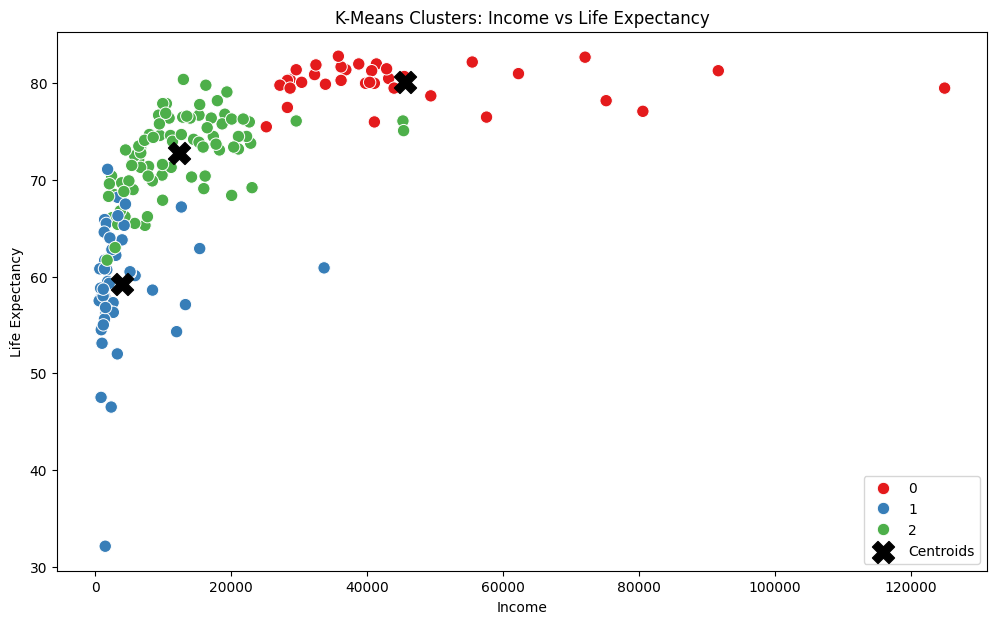

In [ ]:
plt.figure(figsize=(12, 7))

sns.scatterplot(
    data=df,
    x='income',
    y='life_expec',
    hue='Cluster',
    palette='Set1',
    s=80
)

plt.scatter(
    centers_original[:, features.columns.get_loc('income')],
    centers_original[:, features.columns.get_loc('life_expec')],
    marker='X',
    s=250,
    c='black',
    label='Centroids'
)

plt.xlabel("Income")
plt.ylabel("Life Expectancy")
plt.title("K-Means Clusters: Income vs Life Expectancy")
plt.legend()

plt.show()

In [ ]:
cluster_profile = df.groupby('Cluster')[features.columns].mean()

display(cluster_profile)

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
Cluster,,,,,,,,,
0,5.000000,58.738889,8.807778,51.491667,45672.222222,2.671250,80.127778,1.752778,42494.444444
1,92.961702,29.151277,6.388511,42.323404,3942.404255,12.019681,59.187234,5.008085,1922.382979
2,21.927381,40.243917,6.200952,47.473404,12305.595238,7.600905,72.814286,2.307500,6486.452381


In [ ]:
cluster_profile = cluster_profile.round(2)

display(cluster_profile)

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
Cluster,,,,,,,,,
0,5.00,58.74,8.81,51.49,45672.22,2.67,80.13,1.75,42494.44
1,92.96,29.15,6.39,42.32,3942.40,12.02,59.19,5.01,1922.38
2,21.93,40.24,6.20,47.47,12305.60,7.60,72.81,2.31,6486.45


In [ ]:
# Create a simple development score
profile = df.groupby('Cluster')[[
    'child_mort',
    'income',
    'life_expec',
    'gdpp'
]].mean()

profile['development_score'] = (
    profile['income'].rank() +
    profile['life_expec'].rank() +
    profile['gdpp'].rank() -
    profile['child_mort'].rank()
)

profile = profile.sort_values('development_score')

display(profile)

,child_mort,income,life_expec,gdpp,development_score
Cluster,,,,,
1,92.961702,3942.404255,59.187234,1922.382979,0.0
2,21.927381,12305.595238,72.814286,6486.452381,4.0
0,5.000000,45672.222222,80.127778,42494.444444,8.0


In [ ]:
sorted_clusters = profile.index.tolist()

cluster_labels = {
    sorted_clusters[0]: 'Underdeveloped',
    sorted_clusters[1]: 'Developing',
    sorted_clusters[2]: 'Developed'
}

df['Development_Level'] = df['Cluster'].map(cluster_labels)

df[['country', 'Cluster', 'Development_Level']].head(20)

,country,Cluster,Development_Level
0,Afghanistan,1,Underdeveloped
1,Albania,2,Developing
2,Algeria,2,Developing
3,Angola,1,Underdeveloped
4,Antigua and Barbuda,2,Developing
5,Argentina,2,Developing
6,Armenia,2,Developing
7,Australia,0,Developed
8,Austria,0,Developed
9,Azerbaijan,2,Developing


In [ ]:
final_profile = df.groupby(
    ['Cluster', 'Development_Level']
)[features.columns].mean().round(2)

display(final_profile)

,,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
Cluster,Development_Level,,,,,,,,,
0,Developed,5.00,58.74,8.81,51.49,45672.22,2.67,80.13,1.75,42494.44
1,Underdeveloped,92.96,29.15,6.39,42.32,3942.40,12.02,59.19,5.01,1922.38
2,Developing,21.93,40.24,6.20,47.47,12305.60,7.60,72.81,2.31,6486.45


In [ ]:
underdeveloped = df[
    df['Development_Level'] == 'Underdeveloped'
].copy()

# Scale important indicators
priority_scaler = StandardScaler()

priority_features = underdeveloped[
    ['child_mort', 'income', 'life_expec', 'gdpp']
]

priority_scaled = priority_scaler.fit_transform(priority_features)

priority_scaled = pd.DataFrame(
    priority_scaled,
    columns=['child_mort', 'income', 'life_expec', 'gdpp'],
    index=underdeveloped.index
)

# Higher child mortality is worse
# Lower income, life expectancy and GDPP are worse
underdeveloped['Priority_Score'] = (
    priority_scaled['child_mort']
    - priority_scaled['income']
    - priority_scaled['life_expec']
    - priority_scaled['gdpp']
)

# Sort highest priority first
top_10 = underdeveloped.sort_values(
    'Priority_Score',
    ascending=False
).head(10)

display(
    top_10[
        [
            'country',
            'child_mort',
            'income',
            'life_expec',
            'gdpp',
            'Priority_Score'
        ]
    ]
)

,country,child_mort,income,life_expec,gdpp,Priority_Score
66,Haiti,208.0,1500,32.1,662,8.601891
31,Central African Republic,149.0,888,47.5,446,4.582673
132,Sierra Leone,160.0,1220,55.0,399,3.695867
32,Chad,150.0,1930,56.5,897,2.860202
87,Lesotho,99.7,2380,46.5,1170,2.731554
64,Guinea-Bissau,114.0,1390,55.6,547,2.127510
37,"Congo, Dem. Rep.",116.0,609,57.5,334,2.102786
97,Mali,137.0,1870,59.5,708,2.071240
112,Niger,123.0,814,58.8,348,2.069340
106,Mozambique,101.0,918,54.5,419,2.034683


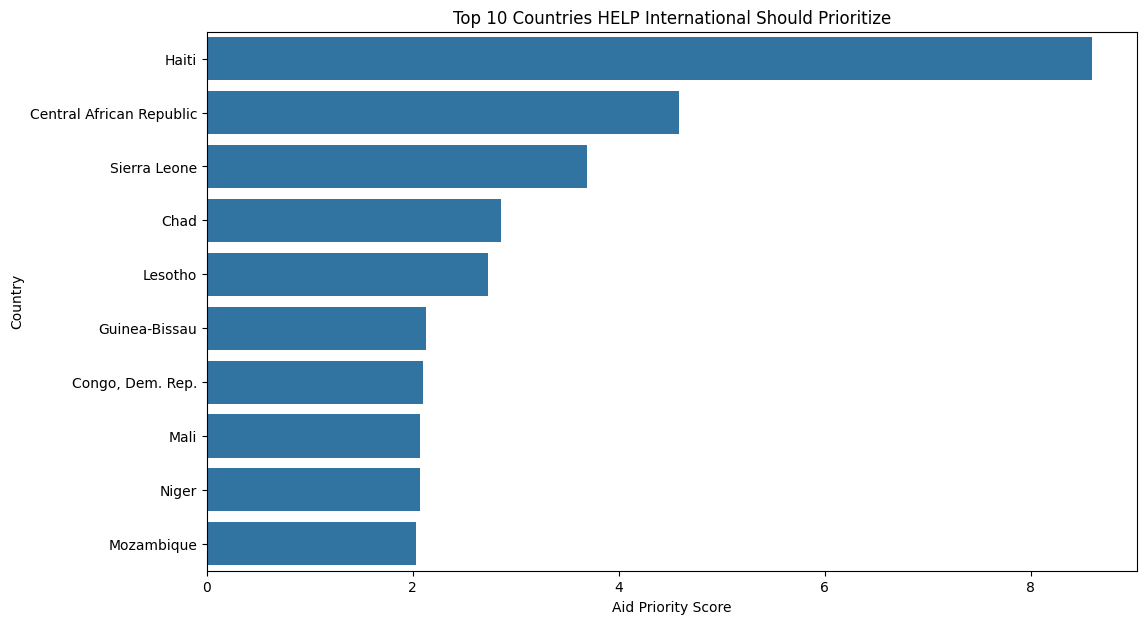

In [ ]:
plt.figure(figsize=(12, 7))

sns.barplot(
    data=top_10,
    x='Priority_Score',
    y='country'
)

plt.xlabel("Aid Priority Score")
plt.ylabel("Country")
plt.title("Top 10 Countries HELP International Should Prioritize")

plt.show()